# Energy Analysis for RMT Simulations

This notebook plots energy quantities from simulation results:
- Kinetic Energy (KE)
- Strain Energy (SE)
- Viscous Dissipation Rate (ε)
- Integrated Dissipation (∫ε dt)
- Total Energy (E_total = KE + SE + ∫ε dt)

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import h5py
import os

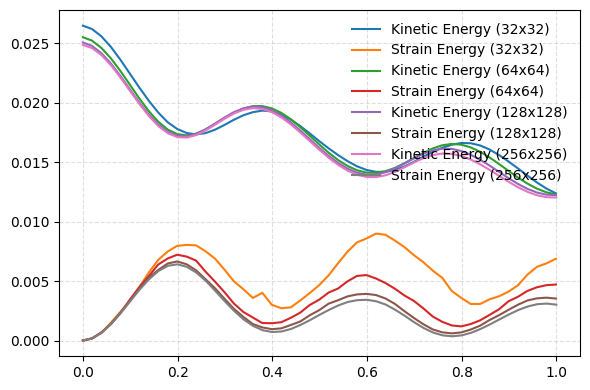

In [50]:
fig, ax = plt.subplots(figsize=(6, 4))

# Specify the output directory
output_dir_32 = "../outputs/output_taylor_green_soft_disc_32x32"
output_dir_64 = "../outputs/output_taylor_green_soft_disc_64x64"
output_dir_128 = "../outputs/output_taylor_green_soft_disc_128x128" 
output_dir_256 = "../outputs/output_taylor_green_soft_disc_256x256" 
output_dirs = [output_dir_32, output_dir_64, output_dir_128, output_dir_256]

# Load energy history CSV
for output_dir in output_dirs:
    energy_file = os.path.join(output_dir, "energy_history.csv")
    df = pd.read_csv(energy_file)
    ax.plot(df["time"], df["kinetic_energy"], label=f"Kinetic Energy ({output_dir.split('_')[-1]})")
    ax.plot(df["time"], df["strain_energy"], label=f"Strain Energy ({output_dir.split('_')[-1]})")
    
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="best", frameon=False)

fig.tight_layout()


In [51]:
# plot the accuracy level at time t=0.399
for output_dir in output_dirs:
    file_path = os.path.join(output_dir, "data_001000.h5")
    with h5py.File(file_path, "r") as f:
        total_energy = f.attrs["total_energy"]
        print(f"Total Energy at t=0.4 in {output_dir}: {total_energy}"  )

Total Energy at t=0.4 in ../outputs/output_taylor_green_soft_disc_32x32: 0.029010383621633613
Total Energy at t=0.4 in ../outputs/output_taylor_green_soft_disc_64x64: 0.02844512263282656
Total Energy at t=0.4 in ../outputs/output_taylor_green_soft_disc_128x128: 0.02872898013010631
Total Energy at t=0.4 in ../outputs/output_taylor_green_soft_disc_256x256: 0.028239110317882673


In [52]:
print(f"Total Energy at t=0.4 in {output_dir}: {total_energy}"  )

Total Energy at t=0.4 in ../outputs/output_taylor_green_soft_disc_256x256: 0.028239110317882673
